In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import sys
sys.path.insert(0, '..')

from mcmc_polymer.polymer import PolymerChain
from mcmc_polymer.rosenbluth import RosenbluthMCMC

## Cubic-Lattice Rosenbluth (R&R 1955 exact setup)

`LatticeRosenbluthMCMC` grows chains on a **simple cubic lattice** — discrete ±x/±y/±z steps, self-avoiding constraint enforced against visited sites, Rosenbluth weight = ∏ (free_neighbors / 6).  This matches the original 1955 paper and should agree closely with its published R_ee values.

In [4]:
import importlib
import numpy as np
import sys
sys.path.insert(0, '..')

import mcmc_polymer.lattice_rosenbluth as _lr_mod
importlib.reload(_lr_mod)
from mcmc_polymer.lattice_rosenbluth import LatticeRosenbluthMCMC

# CHAIN_LENGTHS = bond count N (paper convention).
# The sampler needs n_monomers = N + 1 because the loop runs n_monomers-1 times.
CHAIN_LENGTHS = [8, 16, 32, 64]
N_CHAINS = 10000
start_position = np.array([0.0, 0.0, 0.0])

# Rosenbluth & Rosenbluth (1955) Table I, simple cubic lattice
# Key: N = number of bonds  |  Value: <R²> weighted Rosenbluth average
RR1955_R2 = {
    8:  12.81,
    16: 29.80,
    32: 68.35,
    64: 162.40,
}

lattice_results = {}

for N in CHAIN_LENGTHS:
    print(f"Growing {N_CHAINS} chains, N={N} bonds ({N+1} monomers) ...")
    sampler = LatticeRosenbluthMCMC(n_monomers=N + 1)
    chains, weights = sampler.sample(N_CHAINS, start=start_position)
    weights = np.array(weights)
    r_sq    = np.array([np.sum((c[-1] - c[0]) ** 2) for c in chains])

    n_dead    = int(np.sum(weights == 0))
    w_sum     = weights.sum()
    w_r2_mean = np.sum(weights * r_sq) / w_sum
    w_r2_std  = np.sqrt(np.sum(weights * (r_sq - w_r2_mean) ** 2) / w_sum)

    lattice_results[N] = {
        'n_dead':    n_dead,
        'w_r2_mean': w_r2_mean,
        'w_r2_std':  w_r2_std,
        'published': RR1955_R2[N],
    }

print()
print("Cubic-Lattice Rosenbluth  ⟨R²⟩  vs. Rosenbluth & Rosenbluth (1955) Table I")
print("=" * 78)
print(f"{'N':>5}  {'Dead':>6}  {'⟨R²⟩ (weighted)':>22}  {'distrib. std':>13}  {'R&R 1955':>10}  {'Δ%':>7}")
print("-" * 78)
for n in CHAIN_LENGTHS:
    r = lattice_results[n]
    diff = 100 * (r['w_r2_mean'] - r['published']) / r['published']
    print(f"{n:>5}  {r['n_dead']:>6}  "
          f"{r['w_r2_mean']:>8.2f} ± {r['w_r2_std']:<6.2f}  "
          f"{r['w_r2_std']:>13.2f}  "
          f"{r['published']:>10.2f}  {diff:>+6.1f}%")
print("=" * 78)
print("N = bonds (paper convention). Dead = dead-end chains (w=0, r²=0).")


Growing 10000 chains, N=8 bonds (9 monomers) ...
Growing 10000 chains, N=16 bonds (17 monomers) ...
Growing 10000 chains, N=32 bonds (33 monomers) ...
Growing 10000 chains, N=64 bonds (65 monomers) ...

Cubic-Lattice Rosenbluth  ⟨R²⟩  vs. Rosenbluth & Rosenbluth (1955) Table I
    N    Dead         ⟨R²⟩ (weighted)   distrib. std    R&R 1955       Δ%
------------------------------------------------------------------------------
    8       0     12.84 ± 7.46             7.46       12.81    +0.3%
   16       0     29.59 ± 18.72           18.72       29.80    -0.7%
   32       7     68.34 ± 45.55           45.55       68.35    -0.0%
   64      41    152.76 ± 104.93         104.93      162.40    -5.9%
N = bonds (paper convention). Dead = dead-end chains (w=0, r²=0).


## Rosenbluth + Pivot Algorithm

Each sample is generated by:
1. Growing an initial valid SAW with `LatticeRosenbluthMCMC`
2. Running **20 pivot steps** to decorrelate the configuration
3. Recording the final chain's R²

100 samples are collected per chain length (N = 8, 16, 32, 64 bonds).

In [5]:
import importlib
import numpy as np
import sys
sys.path.insert(0, '..')

import mcmc_polymer.lattice_rosenbluth as _lr_mod
import mcmc_polymer.pivot_alg as _pv_mod
importlib.reload(_lr_mod)
importlib.reload(_pv_mod)
from mcmc_polymer.lattice_rosenbluth import LatticeRosenbluthMCMC
from mcmc_polymer.pivot_alg import PivotAlgorithm

CHAIN_LENGTHS  = [8, 16, 32, 64]
N_SAMPLES      = 1000
N_PIVOT_STEPS  = 30
start_position = np.array([0.0, 0.0, 0.0])

pivot_results = {}

for N in CHAIN_LENGTHS:
    ros_sampler   = LatticeRosenbluthMCMC(n_monomers=N + 1)
    pivot_sampler = PivotAlgorithm(n_steps=N_PIVOT_STEPS)

    r_sq_samples = []

    for _ in range(N_SAMPLES):
        # grow a valid initial chain (retry on dead-ends)
        chain, weight = ros_sampler.grow_chain(start=start_position)
        while weight == 0:
            chain, weight = ros_sampler.grow_chain(start=start_position)

        # decorrelate with pivot moves
        chain, _ = pivot_sampler.run(chain)

        r_sq_samples.append(np.sum((chain[-1] - chain[0]) ** 2))

    r_sq_samples = np.array(r_sq_samples)
    pivot_results[N] = {
        'mean': np.mean(r_sq_samples),
        'std':  np.std(r_sq_samples),
    }
    print(f"N={N:>2}  ⟨R²⟩ = {pivot_results[N]['mean']:.2f} ± {pivot_results[N]['std']:.2f}")

print()
print("Rosenbluth + Pivot  ⟨R²⟩  summary")
print("=" * 52)
print(f"{'N':>5}  {'⟨R²⟩ (unweighted)':>22}  {'R&R 1955':>10}")
print("-" * 52)
RR1955_R2 = {8: 12.81, 16: 29.80, 32: 68.35, 64: 162.40}
for n in CHAIN_LENGTHS:
    r = pivot_results[n]
    print(f"{n:>5}  {r['mean']:>8.2f} ± {r['std']:<8.2f}  {RR1955_R2[n]:>10.2f}")
print("=" * 52)
print("Pivot moves generate uniform SAW samples — no Rosenbluth reweighting needed.")


N= 8  ⟨R²⟩ = 12.49 ± 7.29
N=16  ⟨R²⟩ = 28.96 ± 18.87
N=32  ⟨R²⟩ = 65.11 ± 43.20
N=64  ⟨R²⟩ = 149.86 ± 103.02

Rosenbluth + Pivot  ⟨R²⟩  summary
    N       ⟨R²⟩ (unweighted)    R&R 1955
----------------------------------------------------
    8     12.49 ± 7.29           12.81
   16     28.96 ± 18.87          29.80
   32     65.11 ± 43.20          68.35
   64    149.86 ± 103.02        162.40
Pivot moves generate uniform SAW samples — no Rosenbluth reweighting needed.


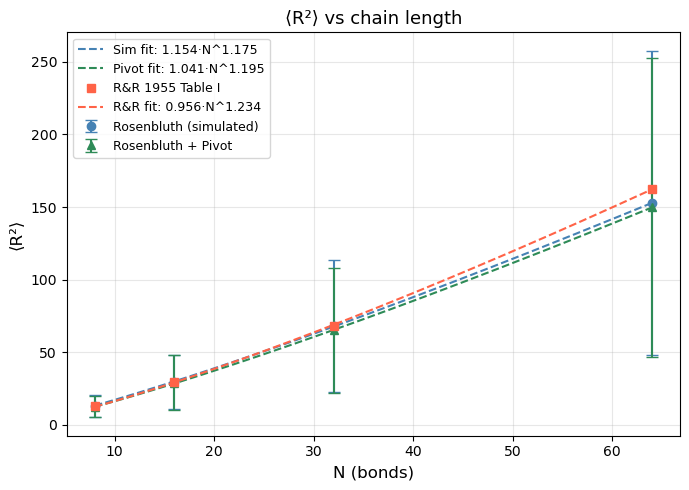

Rosenbluth sim fit :  ⟨R²⟩ = 1.154 · N^1.175
Rosenbluth + Pivot :  ⟨R²⟩ = 1.041 · N^1.195
R&R 1955 fit       :  ⟨R²⟩ = 0.956 · N^1.234
Expected 3D SAW    :  2ν ≈ 1.176  (ν = 0.588)


In [7]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

N_arr      = np.array(CHAIN_LENGTHS, dtype=float)
sim_mean   = np.array([lattice_results[n]['w_r2_mean'] for n in CHAIN_LENGTHS])
sim_std    = np.array([lattice_results[n]['w_r2_std']  for n in CHAIN_LENGTHS])
pub_values = np.array([RR1955_R2[n]                   for n in CHAIN_LENGTHS])
piv_mean   = np.array([pivot_results[n]['mean']        for n in CHAIN_LENGTHS])
piv_std    = np.array([pivot_results[n]['std']         for n in CHAIN_LENGTHS])

def power_law(n, a, nu):
    return a * n ** nu

popt_sim, _ = curve_fit(power_law, N_arr, sim_mean,  p0=[1.0, 1.2])
popt_pub, _ = curve_fit(power_law, N_arr, pub_values, p0=[1.0, 1.2])
popt_piv, _ = curve_fit(power_law, N_arr, piv_mean,  p0=[1.0, 1.2])

N_fit = np.linspace(N_arr[0], N_arr[-1], 300)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(N_arr, sim_mean, yerr=sim_std, fmt='o', capsize=4,
            color='steelblue', label='Rosenbluth (simulated)', zorder=5)
ax.plot(N_fit, power_law(N_fit, *popt_sim), '--', color='steelblue',
        label=f'Sim fit: {popt_sim[0]:.3f}·N^{popt_sim[1]:.3f}')

ax.errorbar(N_arr, piv_mean, yerr=piv_std, fmt='^', capsize=4,
            color='seagreen', label='Rosenbluth + Pivot', zorder=5)
ax.plot(N_fit, power_law(N_fit, *popt_piv), '--', color='seagreen',
        label=f'Pivot fit: {popt_piv[0]:.3f}·N^{popt_piv[1]:.3f}')

ax.plot(N_arr, pub_values, 's', color='tomato', zorder=6,
        label='R&R 1955 Table I')
ax.plot(N_fit, power_law(N_fit, *popt_pub), '--', color='tomato',
        label=f'R&R fit: {popt_pub[0]:.3f}·N^{popt_pub[1]:.3f}')

ax.set_xlabel('N (bonds)', fontsize=12)
ax.set_ylabel('⟨R²⟩', fontsize=12)
ax.set_title('⟨R²⟩ vs chain length', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/lattice_rosenbluth_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Rosenbluth sim fit :  ⟨R²⟩ = {popt_sim[0]:.3f} · N^{popt_sim[1]:.3f}")
print(f"Rosenbluth + Pivot :  ⟨R²⟩ = {popt_piv[0]:.3f} · N^{popt_piv[1]:.3f}")
print(f"R&R 1955 fit       :  ⟨R²⟩ = {popt_pub[0]:.3f} · N^{popt_pub[1]:.3f}")
print(f"Expected 3D SAW    :  2ν ≈ 1.176  (ν = 0.588)")
